In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv"

# Loading ~540,000 rows with special character encoding
df_retail = pd.read_csv(url, encoding='latin1')

print("Dataset Shape:", df_retail.shape)
print("\nFirst 5 rows:")
print(df_retail.head())

Dataset Shape: (541909, 8)

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

    InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/10 8:26       2.55     17850.0  United Kingdom  
1  12/1/10 8:26       3.39     17850.0  United Kingdom  
2  12/1/10 8:26       2.75     17850.0  United Kingdom  
3  12/1/10 8:26       3.39     17850.0  United Kingdom  
4  12/1/10 8:26       3.39     17850.0  United Kingdom  


In [41]:
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [42]:
df_retail.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/11 12:50,4.95,12680.0,France


In [43]:
df_retail.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [44]:
df_retail=df_retail[~(df_retail['InvoiceNo'].astype(str).str.startswith('C'))]
df_retail.shape

(532621, 8)

In [45]:
df_retail=df_retail[(df_retail.Quantity > 0)&(df_retail.UnitPrice > 0)]

In [46]:
df_retail.dropna(subset='CustomerID',inplace=True)

In [47]:
df_retail.InvoiceDate=pd.to_datetime(df_retail.InvoiceDate)

C:\Users\engma\AppData\Local\Temp\ipykernel_21360\1101118737.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_retail.InvoiceDate=pd.to_datetime(df_retail.InvoiceDate)


In [48]:
df_retail['total']=df_retail.Quantity *df_retail.UnitPrice

In [49]:
print(df_retail.shape)
df_retail.head()

(397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [50]:
df_retail.groupby('Country').agg({'total':'sum','InvoiceNo':'nunique','CustomerID':'nunique'}).sort_values(by='total',ascending=False).head()

,total,InvoiceNo,CustomerID
Country,,,
United Kingdom,7308391.554,16646,3920
Netherlands,285446.340,94,9
EIRE,265545.900,260,3
Germany,228867.140,457,94
France,209024.050,389,87


In [51]:
df_retail.groupby('CustomerID').agg({'total':'sum','InvoiceNo':'count'}).sort_values(by='total',ascending=False).head(10)

,total,InvoiceNo
CustomerID,,
14646.0,280206.02,2076
18102.0,259657.30,431
17450.0,194550.79,337
16446.0,168472.50,3
14911.0,143825.06,5675
12415.0,124914.53,714
14156.0,117379.63,1400
17511.0,91062.38,963
16029.0,81024.84,242


In [52]:
df_retail['YearMonth']=df_retail['InvoiceDate'].dt.to_period('M')

In [53]:
montly_rev=df_retail.groupby('YearMonth')['total'].sum()

In [54]:
montly_rev

YearMonth
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: total, dtype: float64

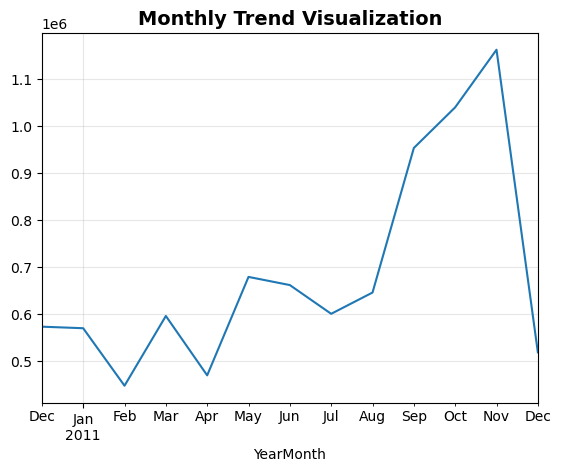

In [55]:
montly_rev.plot()
plt.title('Monthly Trend Visualization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()